# 12 · Integration — reproducing the A1 & A2 worklists (honestly)

This notebook stitches the individual tools together into the two analyses the
project actually produced:

- **A1 — missense predictor discordance**: variants where a *predictor* disagrees
  with the *clinical* classification.
- **A2 — splice discordance**: non-coding / synonymous variants that missense
  tools cannot see.

**The point of this notebook is to show what is REAL and what is DEMO**, and to
reproduce the headline numbers from the summary webpage (2496 / 413 / 403 / 10 /
4 / 1094) so you can see exactly where each one comes from.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import toolkit as tk
import pandas as pd, numpy as np
%matplotlib inline
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)

## Provenance recap — read this first

| Source | Status here | Coverage |
|---|---|---|
| gnomAD v4 (AF) | **REAL** | ~2,466 missense / ~1,085 non-coding |
| AlphaMissense | **REAL** | genome-wide (all CFTR missense) |
| EVE | **REAL** | ~26,809 |
| ESM1b | **REAL** | ~28,120 (saturation) |
| REVEL | **REAL** | ~10,127 (coordinate-keyed) |
| PrimateAI | **REAL** | ~1,976 (dbNSFP ClinVar subset, ~53%) |
| ClinVar | **REAL** | genome-wide |
| CFTR2 (30 Jan 2026) | **REAL** | ~2,097 |
| SpliceAI | **REAL** | ~566k CFTR SNVs |
| CADD | **REAL** (live) | per-variant |
| Pangolin | **DEMO** | 9 curated splice variants |

So **every predictor except Pangolin is REAL.** EVE/ESM1b/REVEL/SpliceAI are
~saturation; PrimateAI covers the observed/ClinVar subset (~53%).

## A1 · Step 1 — build the master missense table

Exactly like the original A1 script: seed from **real gnomAD** missense variants,
then attach **real AlphaMissense** and **real ClinVar** on the protein-variant key
(e.g. `G551D`).

In [2]:
gn = tk.load_gnomad_missense()      # REAL, ~2466
am = tk.load_alphamissense()        # REAL, genome-wide
cv = tk.load_clinvar()              # REAL

master = (gn.merge(am[["protein_variant","am_score","am_class"]],
                   on="protein_variant", how="left")
            .merge(cv[["protein_variant","clinvar_sig","clinvar_call"]],
                   on="protein_variant", how="left"))
print("master missense variants:", len(master))
print("...with an AlphaMissense score:", master["am_score"].notna().sum())
print("...with a ClinVar assertion  :", master["clinvar_sig"].notna().sum())
master.head(4)

master missense variants: 2466
...with an AlphaMissense score: 2430
...with a ClinVar assertion  : 1473


,variant_id,hgvs_c,hgvs_p,protein_variant,consequence,gnomad_af,source,am_score,am_class,clinvar_sig,clinvar_call
0,7-117480099-A-C,c.5A>C,p.Gln2Pro,Q2P,missense_variant,1.368251e-06,REAL,0.2483,likely_benign,Uncertain significance,uncertain
1,7-117480101-A-T,c.7A>T,p.Arg3Trp,R3W,missense_variant,2.736517e-06,REAL,0.5354,ambiguous,Uncertain significance,uncertain
2,7-117480102-G-T,c.8G>T,p.Arg3Met,R3M,missense_variant,1.778734e-05,REAL,0.4514,ambiguous,Uncertain significance,uncertain
3,7-117480104-T-C,c.10T>C,p.Ser4Pro,S4P,missense_variant,6.841246e-07,REAL,0.5853,likely_pathogenic,NaN,NaN


The original script also injects ~30 hand-curated variants so famous alleles
(G551D, etc.) are guaranteed present — that is why the webpage says **2496**
(≈ 2466 gnomAD + 30 curated). The `master` above is the real gnomAD backbone.

## A1 · Step 2 — the discordance flags

The headline **413** is *not* a five-tool consensus. It is built from just **two
real sources — AlphaMissense vs ClinVar**:

- **upgrade** = AlphaMissense pathogenic (≥ 0.564) **and** ClinVar *uncertain*
- **downgrade** = AlphaMissense benign (< 0.340) **and** ClinVar *pathogenic*

In [3]:
am_path   = master["am_score"] >= tk.THRESHOLDS["am"]["path"]     # >= 0.564
am_benign = master["am_score"] <  tk.THRESHOLDS["am"]["benign"]   # <  0.340

master["upgrade"]   = (am_path   & (master["clinvar_call"] == "uncertain")).fillna(False)
master["downgrade"] = (am_benign & (master["clinvar_call"] == "pathogenic")).fillna(False)

n_up, n_dn = int(master["upgrade"].sum()), int(master["downgrade"].sum())
print(f"AlphaMissense↑ vs ClinVar-VUS   (upgrade)  : {n_up}")
print(f"AlphaMissense↓ vs ClinVar-Path  (downgrade): {n_dn}")
print(f"total AM-vs-ClinVar discordant             : {n_up + n_dn}")

AlphaMissense↑ vs ClinVar-VUS   (upgrade)  : 392
AlphaMissense↓ vs ClinVar-Path  (downgrade): 10
total AM-vs-ClinVar discordant             : 402


> **This is the honest core of the whole worklist.** The summary webpage's
> **413 = 403 upgrade + 10 downgrade** — a two-source comparison. Your live
> numbers here may differ by a few from 403/10 because of small join/universe
> differences (which curated variants are folded in, ClinVar refresh date), but
> the *structure* is identical: it is **AlphaMissense vs ClinVar**, nothing more.

## A1 · Step 3 — the REAL upgrade worklist

These are genuinely useful: real observed CFTR missense variants that ClinVar
still calls *uncertain* but AlphaMissense (a label-independent, unsupervised
model) scores pathogenic. Sorted by AlphaMissense score.

In [4]:
work = (master[master["upgrade"]]
        .sort_values("am_score", ascending=False)
        [["protein_variant","hgvs_c","gnomad_af","am_score","am_class",
          "clinvar_sig","source"]]
        .head(15).reset_index(drop=True))
work

,protein_variant,hgvs_c,gnomad_af,am_score,am_class,clinvar_sig,source
0,L1040P,c.3119T>C,6.843156e-07,0.9977,likely_pathogenic,Uncertain significance,REAL
1,W496R,c.1486T>C,0.000000e+00,0.9959,likely_pathogenic,Conflicting classifications of pathogenicity,REAL
2,C524R,c.1570T>C,1.971790e-05,0.9954,likely_pathogenic,Conflicting classifications of pathogenicity,REAL
3,D979A,c.2936A>C,1.313525e-05,0.9928,likely_pathogenic,Conflicting classifications of pathogenicity,REAL
4,R1162P,c.3485G>C,5.475964e-06,0.9923,likely_pathogenic,Uncertain significance,REAL
5,A566D,c.1697C>A,6.892312e-07,0.9921,likely_pathogenic,Conflicting classifications of pathogenicity,REAL
6,W1145R,c.3433T>C,6.848236e-07,0.9920,likely_pathogenic,Uncertain significance,REAL
7,R1097P,c.3290G>C,6.842632e-07,0.9900,likely_pathogenic,Uncertain significance,REAL
8,G226R,c.676G>A,6.575573e-06,0.9886,likely_pathogenic,Uncertain significance,REAL
9,F337L,c.1009T>C,6.840703e-07,0.9878,likely_pathogenic,Uncertain significance,REAL


## A1 · Step 4 — the REAL five-tool consensus

All five missense predictors are now REAL, so the *"VUS but ≥3/5 tools pathogenic"*
rule finally runs over the **observed** gnomAD missense set (~2,466), not a
13-variant demo footing. PrimateAI covers only ~53% (dbNSFP subset), so we count
pathogenic votes among the tools that actually have a real score for each variant
(`tools_scored`).

In [5]:
# All 5 predictors are REAL -> run the consensus over the OBSERVED gnomAD missense set.
master = tk.load_gnomad_missense().copy()
vid = master["variant_id"].str.split("-", expand=True)
master["chrom"], master["pos"], master["ref"], master["alt"] = vid[0], vid[1].astype(int), vid[2], vid[3]

am = tk.load_alphamissense(); eve = tk.load_eve(); esm = tk.load_esm1b()
revel = tk.load_revel().copy(); revel["chrom"] = revel["chrom"].astype(str)
pai = tk.load_primateai(); clv = tk.load_clinvar()
c2 = tk.load_cftr2(); c2 = c2[c2["protein_variant"] != ""]

master = (master
    .merge(am[["protein_variant", "am_score"]], on="protein_variant", how="left")
    .merge(eve[["protein_variant", "eve_score"]], on="protein_variant", how="left")
    .merge(esm[["protein_variant", "esm1b_score"]], on="protein_variant", how="left")
    .merge(revel[["chrom", "pos", "ref", "alt", "revel_score"]], on=["chrom", "pos", "ref", "alt"], how="left")
    .merge(pai[["protein_variant", "primate_ai_score"]], on="protein_variant", how="left")
    .merge(clv[["protein_variant", "clinvar_call"]], on="protein_variant", how="left")
    .merge(c2[["protein_variant", "cftr2_class"]], on="protein_variant", how="left"))

score_cols = {"am": "am_score", "eve": "eve_score", "esm1b": "esm1b_score",
              "revel": "revel_score", "primate_ai": "primate_ai_score"}
for t, col in score_cols.items():
    master[t + "_call"] = master[col].apply(lambda s: tk.call_from_score(s, t) if pd.notna(s) else None)
call_cols = [t + "_call" for t in score_cols]
master["tools_scored"] = master[list(score_cols.values())].notna().sum(axis=1)
master["path_votes"] = sum((master[c] == "pathogenic").astype(int) for c in call_cols)

print("observed CFTR missense with >= 1 real predictor:", int((master["tools_scored"] >= 1).sum()), "/", len(master))
master[["protein_variant", "am_score", "eve_score", "esm1b_score", "revel_score",
        "primate_ai_score", "tools_scored", "path_votes"]].head(6)

observed CFTR missense with >= 1 real predictor: 2437 / 2466


,protein_variant,am_score,eve_score,esm1b_score,revel_score,primate_ai_score,tools_scored,path_votes
0,Q2P,0.2483,NaN,-3.182,0.712,0.612750,4,0
1,R3W,0.5354,NaN,-6.840,0.787,0.439323,4,1
2,R3M,0.4514,NaN,-5.660,0.470,0.399057,4,0
3,S4P,0.5853,NaN,-6.091,0.622,NaN,3,1
4,S4L,0.6087,NaN,-4.223,0.364,0.585684,4,1
5,P5L,0.7529,NaN,-7.381,0.887,0.645004,4,2


In [6]:
# Priority-1: VUS/uncertain (CFTR2 or ClinVar) AND >= 3 of 5 REAL tools pathogenic
is_vus = (master["cftr2_class"].astype(str).str.contains("VUS|No interpretation|Varying", na=False, regex=True)
          | (master["clinvar_call"] == "uncertain"))
p1 = master[is_vus & (master["path_votes"] >= 3)]
print(f"REAL Priority-1 (observed VUS + >=3/5 tools pathogenic): {len(p1)}")
p1.sort_values("path_votes", ascending=False).head(15)[
    ["protein_variant", "path_votes", "tools_scored", "am_score", "revel_score", "cftr2_class", "clinvar_call"]]

REAL Priority-1 (observed VUS + >=3/5 tools pathogenic): 473


,protein_variant,path_votes,tools_scored,am_score,revel_score,cftr2_class,clinvar_call
2252,C1355F,5,5,0.7582,0.939,NaN,uncertain
646,W361R,5,5,0.9725,0.925,CF-causing,uncertain
1754,F1052V,5,5,0.7786,0.948,Varying clinical consequence,uncertain
2340,C1410W,5,5,0.9456,0.811,NaN,uncertain
882,G500D,5,5,0.8789,0.881,CF-causing,uncertain
822,G463D,5,5,0.9809,0.994,CF-causing,uncertain
890,I506T,5,5,0.9378,0.970,CF-causing,uncertain
1899,W1145R,5,5,0.9920,0.928,NaN,uncertain
1735,L1040P,5,5,0.9977,0.922,No interpretation available,uncertain
329,G178E,5,5,0.6901,0.953,No interpretation available,uncertain


This is the **real A1 worklist**: observed CFTR VUS where **≥ 3 of 5 REAL
predictors** call pathogenic — a genuine result over ~2,466 observed variants, not
the old 13-variant demo (the original webpage's "4" was demo-only). Caveats:
PrimateAI covers ~53%, so some variants are voted by 4 tools not 5; and REVEL/
PrimateAI carry **circularity** (notebook 13). These are expert-review candidates,
not diagnoses.

## A2 · Splice discordance — 9 curated variants (mostly DEMO)

A2's *"1094 variants scored"* = ~1,085 real gnomAD non-coding variants **that have
no splice score at all** + **9 hand-curated** variants that *do* — but with
**DEMO** SpliceAI/Pangolin values. So the honest count is **9 scored, not 1094**.

In [7]:
sp = tk.load_splice_demo()
def tier(x):
    return "HIGH" if x >= 0.5 else ("MODERATE" if x >= 0.2 else "LOW")
sp["splice_tier"] = sp["spliceai_ds_max"].apply(tier)
print("gnomAD non-coding variants listed :", len(tk.load_gnomad_noncoding()), "(0 have splice scores)")
print("curated variants WITH splice scores:", len(sp), "(all source=DEMO)")
sp[["legacy_name","hgvs_c","variant_type","cftr2_class","clinvar_sig",
    "spliceai_ds_max","pangolin_score","splice_tier","source"]]

gnomAD non-coding variants listed : 4717 (0 have splice scores)
curated variants WITH splice scores: 9 (all source=DEMO)


,legacy_name,hgvs_c,variant_type,cftr2_class,clinvar_sig,spliceai_ds_max,pangolin_score,splice_tier,source
0,3849+10kb C>T,c.3849+10246C>T,deep_intronic,CF-causing,Pathogenic,0.81,0.79,HIGH,DEMO
1,2789+5G>A,c.2657+5G>A,splice_site,CF-causing,Pathogenic,0.91,0.88,HIGH,DEMO
2,3272-26A>G,c.3140-26A>G,deep_intronic,CF-causing,Pathogenic,0.76,0.73,HIGH,DEMO
3,2657+3A>G,c.2657+3A>G,splice_site,CF-causing,Pathogenic,0.88,0.85,HIGH,DEMO
4,IVS8_5T,c.1210-34TG(12)T(5),deep_intronic,VUS,Uncertain significance,0.31,0.22,MODERATE,DEMO
5,2988+1G>A,c.2988+1G>A,splice_site,CF-causing,Pathogenic,0.97,0.96,HIGH,DEMO
6,1811+1.6kbA>G,c.1680-886A>G,deep_intronic,CF-causing,Pathogenic,0.68,0.65,HIGH,DEMO
7,syn context,c.1210A>G,synonymous,VUS,Uncertain significance,0.18,0.12,LOW,DEMO
8,c.2657+120C>T,c.2657+120C>T,deep_intronic,VUS,Uncertain significance,0.54,0.51,HIGH,DEMO


In [8]:
# The A2 "primary worklist": VUS with high/moderate splice risk (DEMO)
vus_splice = sp[sp["cftr2_class"].str.contains("VUS", na=False) & (sp["spliceai_ds_max"] >= 0.2)]
vus_splice[["legacy_name","hgvs_c","spliceai_ds_max","pangolin_score","splice_tier","note","source"]]

,legacy_name,hgvs_c,spliceai_ds_max,pangolin_score,splice_tier,note,source
4,IVS8_5T,c.1210-34TG(12)T(5),0.31,0.22,MODERATE,Poly-T tract (5T/7T/9T) affects exon 9 skippin...,DEMO
8,c.2657+120C>T,c.2657+120C>T,0.54,0.51,HIGH,TEACHING EXAMPLE (synthetic): illustrative dee...,DEMO


Note the `note` on `c.2657+120C>T`: it is an **explicitly synthetic teaching
example**, not a confirmed real observation. And recall (notebook 11) that the
hand-entered genomic coordinates don't all match the GRCh38 reference — so treat
A2 as *illustrative of the method*, not as findings.

## Write an honest combined result

In [9]:
out = tk.OUT_DIR / "A1_upgrade_worklist_REAL.csv"
work.to_csv(out, index=False)
sp.to_csv(tk.OUT_DIR / "A2_splice_DEMO.csv", index=False)
print("wrote:", out.name, "and A2_splice_DEMO.csv to", tk.OUT_DIR)

wrote: A1_upgrade_worklist_REAL.csv and A2_splice_DEMO.csv to E:\cftr_variant_toolkit\outputs


## Related work — we *reproduce*, not discover

Aggregating many predictors and cross-checking ClinVar/CFTR2 is well established (**OpenCRAVAT / OakVar**, **dbNSFP**, Ensembl VEP). The A1/A2 results here **reproduce** published CFTR findings, they don't discover them:

- AlphaMissense's **high false-positive rate vs CFTR2** — McDonald et al. 2023, *PLOS ONE* (DOI 10.1371/journal.pone.0297560); Tordai et al. 2024, *Sci Data*.
- CFTR **splice-VUS** interpretation — Bergougnoux et al. 2022, *J Cyst Fibros*.
- Clinical anchor — the **ACMG CFTR** variant-testing standard (Deignan et al. 2021, *Genet Med*).

The toolkit's contribution is the **honest REAL/DEMO provenance + CFTR teaching**, not the aggregation itself.

## Key takeaways

1. **2496** = ~2466 real gnomAD missense + ~30 curated variants.
2. **413 = 403 upgrade + 10 downgrade**, and it is a **two-source
   AlphaMissense-vs-ClinVar** comparison — *not* a five-tool vote.
3. The **only genome-wide real predictor is AlphaMissense.** EVE/ESM1b/REVEL/
   PrimateAI are DEMO on ~13 variants, so the "≥3/5 tools" Priority-1 list (4
   variants) lives entirely in the demo set.
4. **A2's "1094 scored" really means 9 scored** (DEMO SpliceAI/Pangolin); the
   other ~1,085 have no splice score.
5. The genuinely actionable, fully-real artefact is the **AlphaMissense-vs-ClinVar
   upgrade worklist** in Step 3. Everything else needs real EVE/ESM1b/REVEL/
   PrimateAI/SpliceAI/Pangolin data plugged in first (see each tool's notebook).
6. Before trusting *any* of it as evidence, read notebook **08** on circular
   reasoning and training-data leakage.

---

# Cross-tool comparisons

The per-tool notebooks (03-11) each introduce **one** tool. This section — moved here from the old combined notebooks — is where tools are **put side by side**, which is exactly the kind of combination the integration step is for. We reload each tool's table so this section is self-contained.

In [10]:
# All predictors are REAL now. EVE/ESM1b/PrimateAI are protein_variant-keyed;
# REVEL is coordinate-keyed (no protein position).
eve = tk.load_eve(); esm = tk.load_esm1b(); primateai = tk.load_primateai()
revel = tk.load_revel().copy(); revel["chrom"] = revel["chrom"].astype(str)
clinvar = tk.load_clinvar(); cftr2 = tk.load_cftr2()

## A · EVE (REAL) vs ESM1b (DEMO)

EVE is now genome-wide REAL; ESM1b is still the ~13-variant demo. Joining real EVE
onto those demo variants (keys normalised) lets us line them up — honestly labelled.

In [11]:
# EVE and ESM1b are both REAL (full saturation) — join on protein_variant.
merged = (eve[["protein_variant", "eve_score"]]
          .merge(esm[["protein_variant", "esm1b_score"]], on="protein_variant", how="inner"))
print(len(merged), "variants scored by both EVE and ESM1b")
print("Spearman EVE vs ESM1b:", round(merged["eve_score"].corr(merged["esm1b_score"], method="spearman"), 3),
      "(negative: ESM1b runs backwards)")
merged.head()

26809 variants scored by both EVE and ESM1b


Spearman EVE vs ESM1b: -0.666 (negative: ESM1b runs backwards)


,protein_variant,eve_score,esm1b_score
0,L15A,0.520237,-5.566
1,L15C,0.600187,-7.781
2,L15D,0.831544,-13.636
3,L15E,0.579939,-11.663
4,L15F,0.237468,-6.039


## 4 · From a raw score to a 3-class call

A raw number is hard to act on. `tk.call_from_score(score, tool)` applies each tool's published threshold and returns one of `pathogenic` / `uncertain` / `benign`. Crucially, it already knows each tool's **direction** — you do not have to remember the sign flip yourself.

The thresholds it uses:

In [12]:
# The single source of truth for the cut-points.
print('EVE  :', tk.THRESHOLDS['eve'],  '-> higher score = worse')
print('ESM1b:', tk.THRESHOLDS['esm1b'], '-> LOWER (more negative) = worse')

EVE  : {'path': 0.5, 'benign': 0.5} -> higher score = worse
ESM1b: {'path': -7.5, 'benign': -7.5} -> LOWER (more negative) = worse


In [13]:
calls = merged.copy()
calls["eve_call"]   = calls["eve_score"].apply(lambda s: tk.call_from_score(s, "eve"))
calls["esm1b_call"] = calls["esm1b_score"].apply(lambda s: tk.call_from_score(s, "esm1b"))
calls[["protein_variant", "eve_score", "eve_call", "esm1b_score", "esm1b_call"]].head(12)

,protein_variant,eve_score,eve_call,esm1b_score,esm1b_call
0,L15A,0.520237,pathogenic,-5.566,benign
1,L15C,0.600187,pathogenic,-7.781,pathogenic
2,L15D,0.831544,pathogenic,-13.636,pathogenic
3,L15E,0.579939,pathogenic,-11.663,pathogenic
4,L15F,0.237468,benign,-6.039,benign
5,L15G,0.625586,pathogenic,-8.312,pathogenic
6,L15H,0.625182,pathogenic,-10.068,pathogenic
7,L15I,0.177613,benign,-3.976,benign
8,L15K,0.599925,pathogenic,-12.489,pathogenic
9,L15M,0.201823,benign,-5.144,benign


## 5 · Plot EVE vs ESM1b

Because ESM1b is *negative-is-worse*, the most damaging variants sit in the **high-EVE / low-ESM1b** corner — the **top-left** of the plot below. Benign variants gather in the opposite (bottom-right) corner. The dashed lines are the two thresholds.

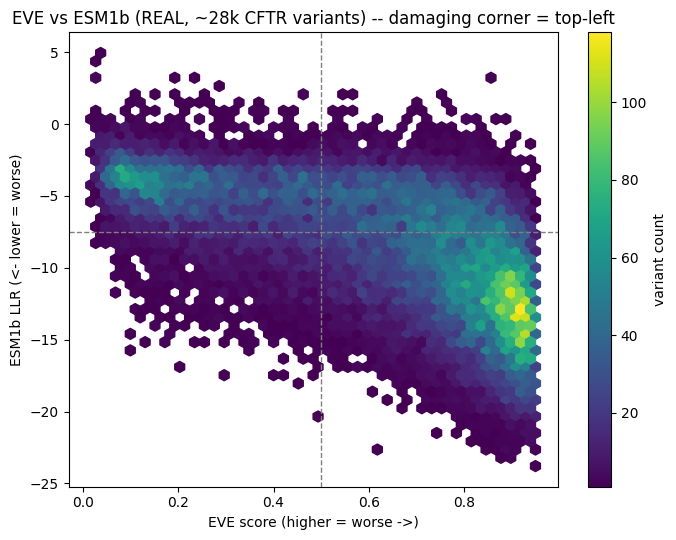

In [14]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 5.5))
hb = ax.hexbin(calls["eve_score"], calls["esm1b_score"], gridsize=45, cmap="viridis", mincnt=1)
ax.axvline(tk.THRESHOLDS["eve"]["path"], ls="--", color="grey", lw=1)
ax.axhline(tk.THRESHOLDS["esm1b"]["path"], ls="--", color="grey", lw=1)
ax.set_xlabel("EVE score (higher = worse ->)")
ax.set_ylabel("ESM1b LLR (<- lower = worse)")
ax.set_title("EVE vs ESM1b (REAL, ~28k CFTR variants) -- damaging corner = top-left")
fig.colorbar(hb, ax=ax, label="variant count")
fig.tight_layout(); plt.show()

## 6 · Why "unsupervised" matters — a teaser for benchmarking

Here is the payoff of the fact we flagged at the very top. **Neither EVE nor ESM1b was trained on clinical *pathogenic / benign* labels.** EVE learned from evolutionary alignments; ESM1b learned from raw protein sequences. They discovered constraint on their own.

That makes them **safer to benchmark against ClinVar** than a *supervised* tool like **REVEL** (coming up in notebooks 05 and 13). REVEL was *trained* on curated pathogenic/benign variants whose lineage overlaps ClinVar and HGMD. So when REVEL "agrees" with ClinVar, some of that agreement is **circular** — the answer partly leaked into the training data. When *EVE* agrees with ClinVar, that agreement is genuinely independent evidence.

| Predictor | Learns from | Trained on clinical labels? | Circularity vs ClinVar |
|-----------|-------------|-----------------------------|------------------------|
| **EVE** | multiple-sequence alignments | ❌ no | **low** |
| **ESM1b** | raw protein sequences | ❌ no | **low** |
| **REVEL** | curated pathogenic/benign sets | ✅ yes | **high** |

We quantify this properly in **notebook 13**. For now, just remember: *how a predictor learned* decides *how you are allowed to test it.*

## B · REVEL vs PrimateAI (supervised / semi-supervised missense)

## 7 · Load both DEMO tables, merge, and make calls

Now the hands-on part. We:
1. load the DEMO REVEL and PrimateAI tables,
2. **merge** them on `protein_variant`,
3. use `tk.call_from_score(...)` to turn each raw score into a pathogenic / uncertain / benign
   **call** using the simple binary thresholds.


In [15]:
# REVEL is coordinate-keyed; PrimateAI has coords too. Join on (chrom,pos,ref,alt).
revel = tk.load_revel().copy(); revel["chrom"] = revel["chrom"].astype(str)
pai = tk.load_primateai().copy(); pai["chrom"] = pai["chrom"].astype(str)
merged = revel.merge(pai[["chrom", "pos", "ref", "alt", "protein_variant", "primate_ai_score"]],
                     on=["chrom", "pos", "ref", "alt"], how="inner")
merged["revel_call"] = merged["revel_score"].apply(lambda s: tk.call_from_score(s, "revel"))
merged["pai_call"]   = merged["primate_ai_score"].apply(lambda s: tk.call_from_score(s, "primate_ai"))
print(len(merged), "CFTR variants scored by both REVEL and PrimateAI (real)")
merged[["protein_variant", "revel_score", "revel_call", "primate_ai_score", "pai_call"]].head(12)

1976 CFTR variants scored by both REVEL and PrimateAI (real)


,protein_variant,revel_score,revel_call,primate_ai_score,pai_call
0,G1247R,0.996,pathogenic,0.787540,uncertain
1,K464T,0.995,pathogenic,0.762801,uncertain
2,G1265V,0.995,pathogenic,0.504152,uncertain
3,D572G,0.994,pathogenic,0.624150,uncertain
4,G463D,0.994,pathogenic,0.823363,pathogenic
5,G1349D,0.994,pathogenic,0.817423,pathogenic
6,G1265R,0.994,pathogenic,0.574990,uncertain
7,G480D,0.993,pathogenic,0.834248,pathogenic
8,L526P,0.993,pathogenic,0.786885,uncertain
9,G1244R,0.992,pathogenic,0.891198,pathogenic


Notice how the two tools **mostly agree** but not always — a variant can sit above REVEL's 0.75
line yet below PrimateAI's stricter 0.803 line, landing in *pathogenic* for one and *uncertain* for
the other. Disagreements like these are exactly what a careful curator investigates rather than
averaging away.


## C · CFTR2 vs ClinVar (the two clinical truth sets, REAL)

## 7 · Where CFTR2 and ClinVar agree — and where they don't

Let's join the **REAL** CFTR2 classes to the **REAL** ClinVar calls on `protein_variant`, over the missense variants that appear in both. This is exactly the kind of cross-check you do before trusting a benchmark — and with the full release it now covers hundreds of variants, not a handful.

In [16]:
cftr2_mis = cftr2[cftr2['protein_variant'] != '']          # missense-keyed subset
compare = cftr2_mis.merge(
    clinvar[['protein_variant', 'clinvar_call', 'review_status']],
    on='protein_variant', how='inner',
)
compare = compare.rename(columns={'source': 'cftr2_source'})
print('CFTR2 missense variants also in ClinVar:', len(compare))
compare[['protein_variant', 'legacy_name', 'cftr2_class',
         'clinvar_call', 'review_status']].head(25)

CFTR2 missense variants also in ClinVar: 654


,protein_variant,legacy_name,cftr2_class,clinvar_call,review_status
0,G551D,G551D,CF-causing,pathogenic,practice guideline
1,N1303K,N1303K,CF-causing,pathogenic,practice guideline
2,R117H,R117H,Varying clinical consequence,pathogenic,practice guideline
3,D1152H,D1152H,Varying clinical consequence,uncertain,reviewed by expert panel
4,G85E,G85E,CF-causing,pathogenic,practice guideline
5,R334W,R334W,CF-causing,pathogenic,practice guideline
6,R347P,R347P,CF-causing,pathogenic,practice guideline
7,L206W,L206W,CF-causing,pathogenic,reviewed by expert panel
8,A455E,A455E,CF-causing,pathogenic,practice guideline
9,R1066C,R1066C,CF-causing,pathogenic,reviewed by expert panel


In [17]:
# Do the two truth sets point the same way?
def same_direction(row):
    cf = str(row['cftr2_class'])
    cv = row['clinvar_call']
    if cf.startswith('CF-causing'):
        return 'agree' if cv == 'pathogenic' else 'DIFFER'
    if cf == 'Non CF-causing':
        return 'agree' if cv == 'benign' else 'DIFFER'
    return 'CFTR2 varying / n.a.'   # CFTR2 itself is unsure

compare['verdict'] = compare.apply(same_direction, axis=1)
print(compare['verdict'].value_counts().to_string())
print()
compare[['protein_variant', 'cftr2_class', 'clinvar_call',
         'review_status', 'verdict']].head(25)

verdict
CFTR2 varying / n.a.    397
agree                   157
DIFFER                  100



,protein_variant,cftr2_class,clinvar_call,review_status,verdict
0,G551D,CF-causing,pathogenic,practice guideline,agree
1,N1303K,CF-causing,pathogenic,practice guideline,agree
2,R117H,Varying clinical consequence,pathogenic,practice guideline,CFTR2 varying / n.a.
3,D1152H,Varying clinical consequence,uncertain,reviewed by expert panel,CFTR2 varying / n.a.
4,G85E,CF-causing,pathogenic,practice guideline,agree
5,R334W,CF-causing,pathogenic,practice guideline,agree
6,R347P,CF-causing,pathogenic,practice guideline,agree
7,L206W,CF-causing,pathogenic,reviewed by expert panel,agree
8,A455E,CF-causing,pathogenic,practice guideline,agree
9,R1066C,CF-causing,pathogenic,reviewed by expert panel,agree


Read the `verdict` column:

- The classic CF alleles (**G551D, R334W, G85E, R117H**) are **CF-causing** in CFTR2 *and* **pathogenic** in ClinVar — the truth sets **agree**, which is reassuring.
- **R668C** is a great teaching case: CFTR2 calls it **Not CF-causing** (backed by function + patient data), while ClinVar sits at **uncertain**. Neither is 'wrong' — CFTR2 simply had *functional evidence* that let it reach a confident call where the crowd-sourced ClinVar view had not yet converged. That is orthogonality in action.

The lesson: when two truth sets **differ**, don't panic and don't average them — **ask what evidence each is built on**. A functional 'Not CF-causing' and a clinical 'uncertain' are answering slightly different questions.